In [1]:
!pip install torchinfo
!pip install --quiet torchview graphviz

In [2]:
import math
import os
import time
from datetime import timedelta
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from IPython.display import SVG, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchinfo import summary
from torchview import draw_graph

import torchvision.models as models

In [3]:
ROOT_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection'
IMG_SIZE = 224
BATCH_SIZE = 6
NUM_WORKERS = 4
RANDOM_STATE = 42

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

ROOT_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection"   # change if needed


# =========================
# APTOS CSV LOADER
# =========================
def load_aptos_annotations(root_dir,
                           csv_name="train.csv",
                           image_folder="train_images"):
    """
    Load APTOS 2019 annotations from train.csv
    
    Returns dataframe with:
    image_path | label
    """

    csv_path = os.path.join(root_dir, csv_name)

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"{csv_path} not found")

    df = pd.read_csv(csv_path)

    required_cols = ["id_code", "diagnosis"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    records = []
    missing_images = 0

    for _, row in df.iterrows():
        img_id = str(row["id_code"]).strip()
        label = int(row["diagnosis"])

        img_path = os.path.join(root_dir, image_folder, img_id + ".png")

        if os.path.isfile(img_path):
            records.append((img_path, label))
        else:
            missing_images += 1

    df_records = pd.DataFrame(records, columns=["image_path", "label"])

    print("========== DATA SUMMARY ==========")
    print("Loaded images:", len(df_records))
    print("Missing images:", missing_images)
    print("Class distribution:")
    print(df_records["label"].value_counts().sort_index())
    print("==================================")

    return df_records


# =========================
# LOAD DATA
# =========================
df_all = load_aptos_annotations(ROOT_DIR)


# =========================
# CLASSES (APTOS = 5)
# =========================
CLASSES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

num_classes = len(CLASSES)


# =========================
# TRAIN / VAL / TEST SPLIT
# =========================
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

========== DATA SUMMARY ==========
Loaded images: 3662
Missing images: 0
Class distribution:
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Split sizes:
Train: 2563
Val: 549
Test: 550


In [5]:
class AptosDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
train_dataset = AptosDataset(train_df, transform=transform)
val_dataset = AptosDataset(val_df, transform=transform)
test_dataset = AptosDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

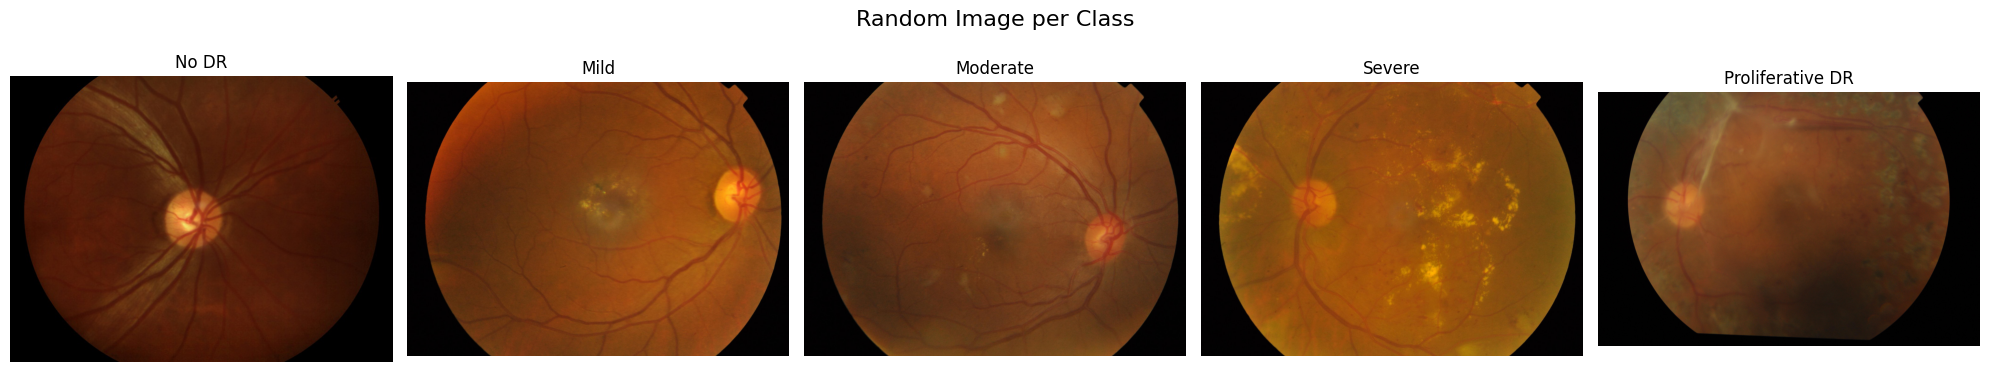

In [8]:
def show_random_images_per_class(df, classes, title="Random Image per Class"):
    num_classes = len(classes)
    fig, axs = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))
    if num_classes == 1:
        axs = [axs]

    for i, cls in enumerate(range(num_classes)):
        class_df = df[df['label'] == cls]
        if len(class_df) == 0:
            axs[i].axis("off")
            axs[i].set_title(f"{classes[cls]}\n(No Images)")
            continue

        row = class_df.sample(n=1).iloc[0]
        image = Image.open(row['image_path']).convert('RGB')
        axs[i].imshow(image)
        axs[i].set_title(classes[cls], fontsize=12)
        axs[i].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
show_random_images_per_class(train_df, CLASSES)

In [9]:
class TinyViT(nn.Module):
    def __init__(self, in_channels=32, embed_dim=32):
        super().__init__()

        # Patch embedding (7x7)
        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=7,
            stride=7
        )

        # depth = 2 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=32,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2   
        )

    def forward(self, x):
        x = self.patch_embed(x)   # (B,32,H/7,W/7)

        B, C, H, W = x.shape

        x = x.view(B, C, H * W).permute(0, 2, 1)  # (B,N,C)

        x = self.transformer(x)

        x = x.mean(dim=1)

        return x

In [10]:
class SAM_ViT_Branch(nn.Module):
    def __init__(self):
        super().__init__()

        # 3x3 → 1x1 conv
        self.conv = nn.Conv2d(
            224, 64,
            kernel_size=1,
            stride=1,
            padding=0
        )
        self.bn1 = nn.BatchNorm2d(64)

        self.dilated = nn.Conv2d(
            64, 32,
            kernel_size=3,
            stride=1,
            dilation=2,
            padding=0
        )
        self.bn2 = nn.BatchNorm2d(32)

        self.act = nn.GELU()

        self.vit = TinyViT(in_channels=32)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='bilinear')  # (B,112,28,28)

        avg = F.avg_pool2d(x, kernel_size=3, stride=1, padding=0)
        max_ = F.max_pool2d(x, kernel_size=3, stride=1, padding=0)

        x = torch.cat([avg, max_], dim=1)   # (B,224,26,26)

        # Now output stays (26,26) → SAME as before
        x = self.conv(x)   
        x = self.bn1(x)

        x = self.dilated(x)   # → (B,32,22,22)
        x = self.bn2(x)

        x = self.act(x)

        vit_feat = self.vit(x)

        return vit_feat

In [11]:
class EfficientNet_SAM_ViT(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        self.features = self.backbone.features

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # SAM + ViT branch
        self.sam_vit = SAM_ViT_Branch()

        # 1280 + 32 
        self.classifier = nn.Linear(1280 + 32, num_classes)

    def forward(self, x):

        spatial_feat = None

        # ===== Backbone =====
        for i, layer in enumerate(self.features):
            x = layer(x)

            if i == 5:
                spatial_feat = x   # (B,112,14,14)

        # ===== Global Branch =====
        global_feat = self.global_pool(x)
        global_feat = torch.flatten(global_feat, 1)  # (B,1280)

        # ===== SAM + ViT Branch =====
        branch_feat = self.sam_vit(spatial_feat)     # (B,32)

        # ===== Fusion =====
        fused = torch.cat([global_feat, branch_feat], dim=1)  # (B,1312)

        # ===== Output =====
        out = self.classifier(fused)

        return out

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNet_SAM_ViT(num_classes).to(device)
model.to(device)
summary(model, input_size=(1, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 173MB/s]


Layer (type:depth-idx)                                       Output Shape              Param #
EfficientNet_SAM_ViT                                         [1, 5]                    1,281,000
├─Sequential: 1-1                                            --                        --
│    └─Conv2dNormActivation: 2-1                             [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                                      [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                                 [1, 32, 112, 112]         64
│    │    └─SiLU: 3-3                                        [1, 32, 112, 112]         --
│    └─Sequential: 2-2                                       [1, 16, 112, 112]         --
│    │    └─MBConv: 3-4                                      [1, 16, 112, 112]         1,448
│    └─Sequential: 2-3                                       [1, 24, 56, 56]           --
│    │    └─MBConv: 3-5                                      [1, 24, 56, 56]        

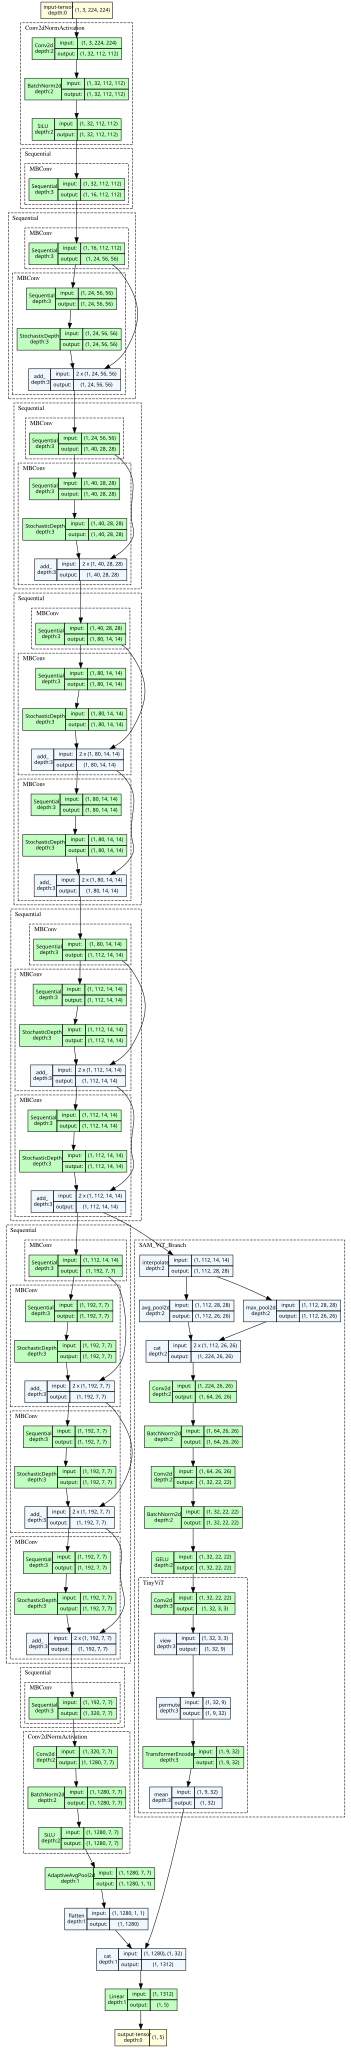

In [13]:
from torchview import draw_graph
from IPython.display import SVG, display

dummy_input = torch.randn(1, 3, 224, 224).to(device)

model_graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True
)

svg = model_graph.visual_graph.pipe(format='svg')

display(SVG(svg))

with open("/kaggle/working/model_graph.svg", "wb") as f:
    f.write(svg)

In [14]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true_numpy = y_true.cpu().numpy()
    y_pred_classes_numpy = y_pred_classes.cpu().numpy()

    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)

    precision = precision_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    recall = recall_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    f1 = f1_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    num_classes = y_pred.shape[1]
    auc_scores = []

    for class_idx in range(num_classes):
        class_y_true = (y_true_numpy == class_idx).astype(np.float32)
        class_y_pred = y_pred[:, class_idx].cpu().numpy()

        if np.unique(class_y_true).size < 2:
            continue

        try:
            auc_score = roc_auc_score(class_y_true, class_y_pred)
            auc_scores.append(auc_score)
        except ValueError:
            continue

    auc_avg = np.mean(auc_scores) if auc_scores else 0.0

    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc_avg,
    }

    return metrics

In [15]:
# Hyperparameters
num_epochs = 30
initial_lr = 0.0005

# Criterion, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# Plateau LR scheduler (fixed — no verbose arg)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.75,
    patience=5
)

In [16]:
import torch
import numpy as np
from tqdm import tqdm

metric_names = ["loss", "accuracy", "precision", "recall", "f1_score", "auc"]

train_metrics_history = {metric: [] for metric in metric_names}
val_metrics_history = {metric: [] for metric in metric_names}

best_val_loss = float("inf")

save_epochs = [7, 15]   # checkpoints to save

# ===== TRAINING LOOP =====
for epoch in range(num_epochs):

    print(f"\n🚀 Epoch [{epoch+1}/{num_epochs}]")

    # ===== TRAIN =====
    model.train()
    total_train_loss = 0.0
    all_train_predictions = []
    all_train_targets = []

    for data, targets in tqdm(train_loader, desc=f"Training Epoch [{epoch+1}/{num_epochs}]"):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        all_train_predictions.extend(outputs.detach().cpu().numpy())
        all_train_targets.extend(targets.detach().cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)

    train_metrics = custom_metrics(
        torch.tensor(np.array(all_train_predictions)),
        torch.tensor(np.array(all_train_targets)),
        avg_train_loss
    )

    print("📊 Train Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in train_metrics.items()]))

    for metric in metric_names:
        train_metrics_history[metric].append(train_metrics[metric])


    # ===== VALIDATION =====
    model.eval()
    total_val_loss = 0.0
    all_val_predictions = []
    all_val_targets = []

    with torch.no_grad():
        for data, targets in tqdm(val_loader, desc="Validating Model"):
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            total_val_loss += loss.item()
            all_val_predictions.extend(outputs.detach().cpu().numpy())
            all_val_targets.extend(targets.detach().cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    val_metrics = custom_metrics(
        torch.tensor(np.array(all_val_predictions)),
        torch.tensor(np.array(all_val_targets)),
        avg_val_loss
    )

    print("📊 Val Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in val_metrics.items()]))

    for metric in metric_names:
        val_metrics_history[metric].append(val_metrics[metric])


    # ===== Save BEST model =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        torch.save(model.state_dict(),
                   "/kaggle/working/best_model_weights.pth")

        torch.save(model,
                   "/kaggle/working/best_model_full.pth")

        print("✅ Best model saved (lowest val loss)")


    # ===== Save CHECKPOINT at specific epochs =====
    if (epoch + 1) in save_epochs:

        torch.save(model.state_dict(),
                   f"/kaggle/working/model_epoch_{epoch+1}_weights.pth")

        torch.save(model,
                   f"/kaggle/working/model_epoch_{epoch+1}_full.pth")

        print(f"📌 Model saved at Epoch {epoch+1}")


    # ===== Scheduler =====
    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"📉 LR after epoch {epoch+1}: {current_lr:.6f}")


🚀 Epoch [1/30]


Training Epoch [1/30]: 100%|██████████| 428/428 [02:05<00:00,  3.40it/s]


📊 Train Metrics - loss: 0.7424, accuracy: 0.7234, precision: 0.6949, recall: 0.7234, f1_score: 0.6965, auc: 0.8684


Validating Model: 100%|██████████| 92/92 [00:27<00:00,  3.36it/s]


📊 Val Metrics - loss: 0.5957, accuracy: 0.7960, precision: 0.7571, recall: 0.7960, f1_score: 0.7672, auc: 0.9087
✅ Best model saved (lowest val loss)
📉 LR after epoch 1: 0.000500

🚀 Epoch [2/30]


...

📊 Val Metrics - loss: 1.1804, accuracy: 0.7887, precision: 0.7864, recall: 0.7887, f1_score: 0.7859, auc: 0.8939
📉 LR after epoch 29: 0.000158

🚀 Epoch [30/30]


Training Epoch [30/30]: 100%|██████████| 428/428 [02:03<00:00,  3.48it/s]


📊 Train Metrics - loss: 0.0250, accuracy: 0.9871, precision: 0.9871, recall: 0.9871, f1_score: 0.9871, auc: 0.9991


Validating Model: 100%|██████████| 92/92 [00:26<00:00,  3.51it/s]

📊 Val Metrics - loss: 1.1213, accuracy: 0.8106, precision: 0.8082, recall: 0.8106, f1_score: 0.8079, auc: 0.8940
📉 LR after epoch 30: 0.000158


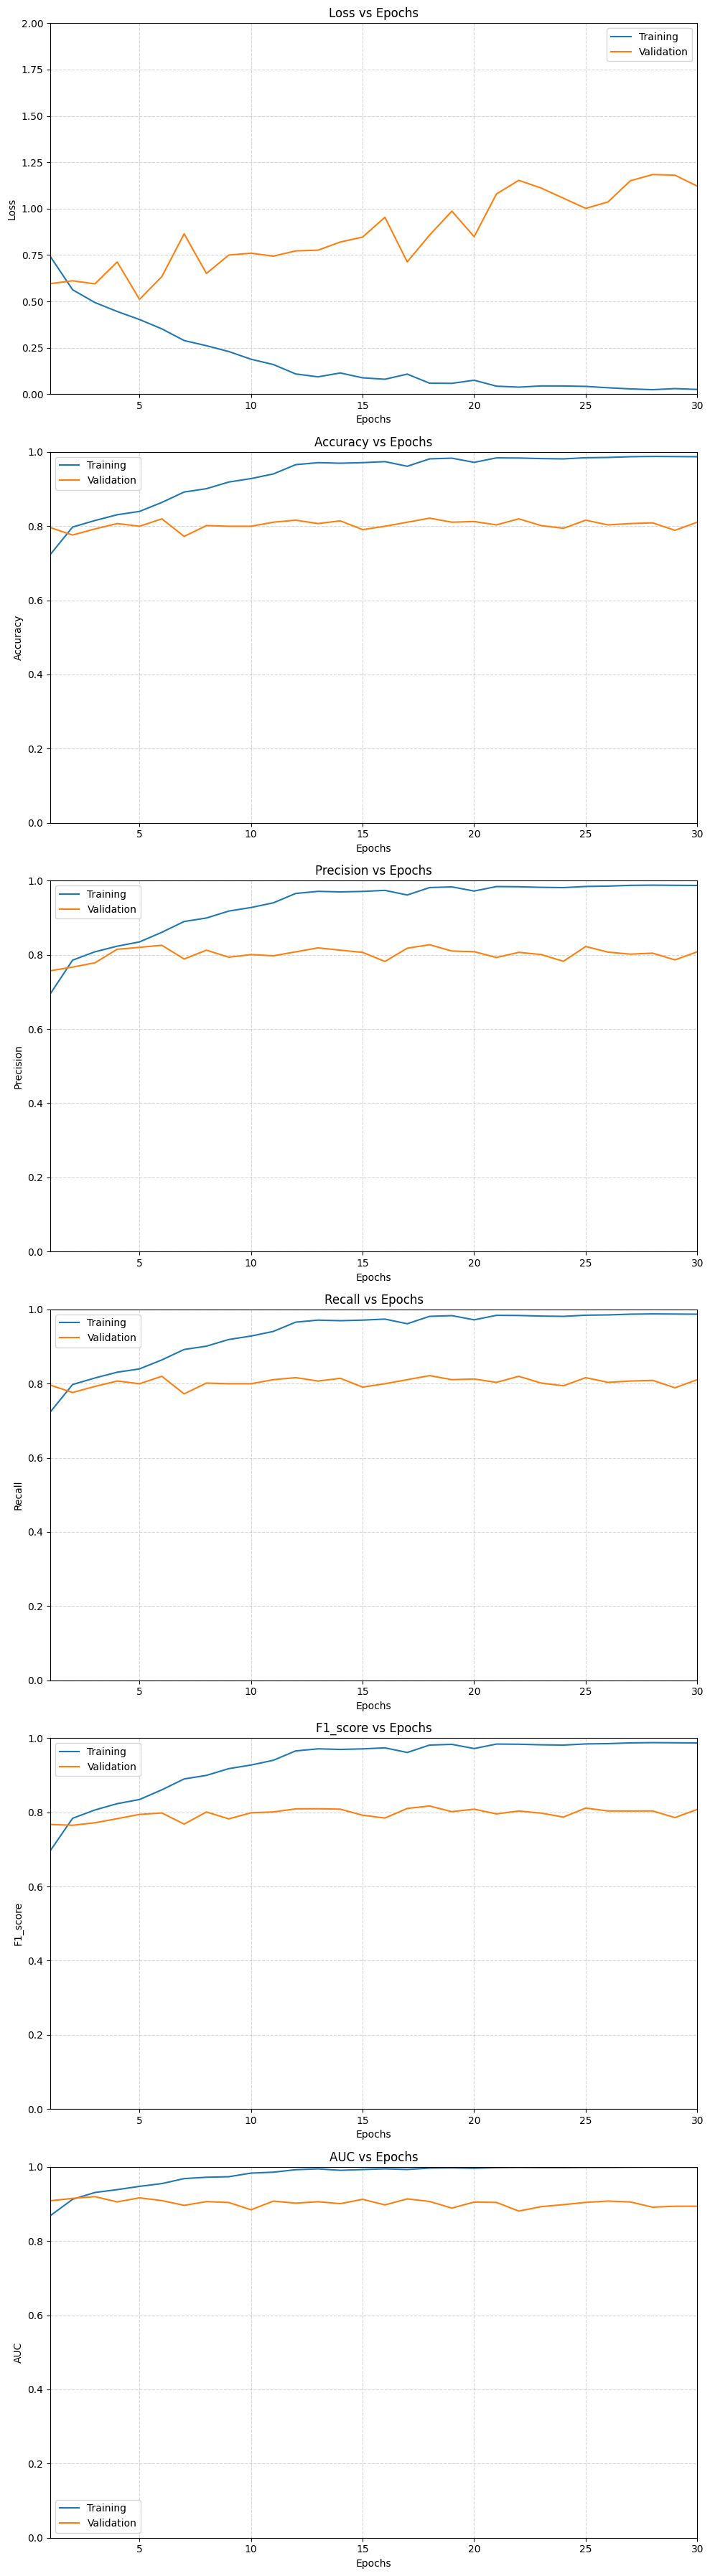

In [19]:
def plot_metrics(train_metrics_history, val_metrics_history, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))
    if num_metrics == 1:
        axes = [axes]

    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):
        train_metric = train_metrics_history[metric_name]
        val_metric = val_metrics_history[metric_name]

        ax.plot(rng, train_metric, label="Training")
        ax.plot(rng, val_metric, label="Validation")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name == "auc":
            ax.set_ylabel("AUC")
            ax.set_title("AUC vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")

        max_metric = max(max(train_metric), max(val_metric))
        min_metric = min(min(train_metric), min(val_metric))
        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)

        if num_epochs == 1:
            ax.set_xlim(0.5, 1.5)
        else:
            ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()


plot_metrics(train_metrics_history, val_metrics_history, metric_names)

In [18]:
state_dict = torch.load("/kaggle/working/model_epoch_30_weights.pth")

model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✅ Best model loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/model_epoch_30_weights.pth'

In [20]:
model.eval()
total_test_loss = 0.0
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(tqdm(test_loader, desc="Testing Model")):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

        all_test_predictions.extend(outputs.detach().cpu().numpy())
        all_test_targets.extend(targets.detach().cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

average_test_loss = total_test_loss / len(test_loader)

test_metrics = custom_metrics(
    torch.tensor(all_test_predictions),
    torch.tensor(all_test_targets),
    average_test_loss
)

testing_metrics_line = "Test Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in test_metrics.items()])
print(testing_metrics_line)

Testing Model: 100%|██████████| 92/92 [00:27<00:00,  3.35it/s]

Test Metrics - loss: 0.8975, accuracy: 0.8400, precision: 0.8398, recall: 0.8400, f1_score: 0.8390, auc: 0.9201


In [21]:
true_labels = np.array(all_test_targets)
predicted_labels = np.argmax(np.array(all_test_predictions), axis=1)

true_labels = true_labels.astype(int)
predicted_labels = predicted_labels.astype(int)

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASSES,
    digits=4
)

accuracy = accuracy_score(true_labels, predicted_labels)
num_errors = np.sum(true_labels != predicted_labels)

print(report)
print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy * 100:6.2f}%')

                  precision    recall  f1-score   support

           No DR     0.9813    0.9705    0.9759       271
            Mild     0.6212    0.7321    0.6721        56
        Moderate     0.8039    0.8200    0.8119       150
          Severe     0.5200    0.4483    0.4815        29
Proliferative DR     0.5789    0.5000    0.5366        44

        accuracy                         0.8400       550
       macro avg     0.7011    0.6942    0.6956       550
    weighted avg     0.8398    0.8400    0.8390       550

There were 88 errors in 550 tests for an accuracy of  84.00%


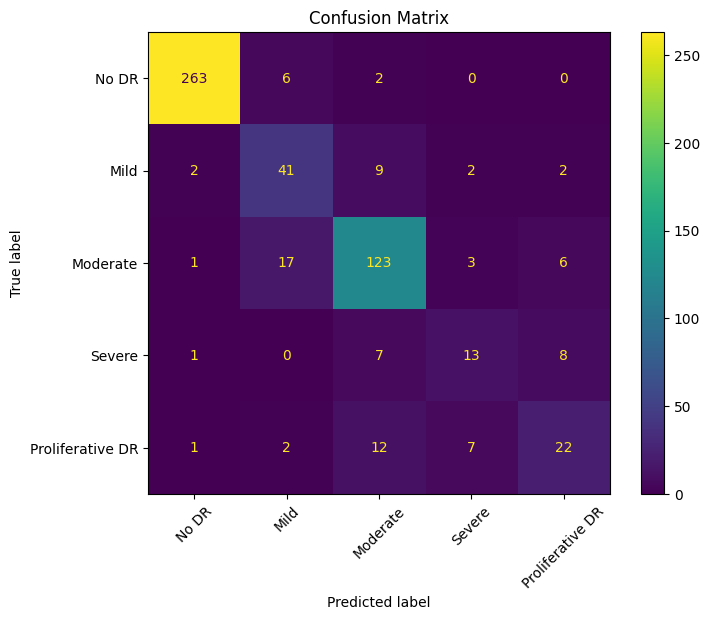

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(true_labels, predicted_labels, class_names):
    cm = confusion_matrix(true_labels, predicted_labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax)

    plt.title("Confusion Matrix")
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

plot_confusion_matrix(true_labels, predicted_labels, CLASSES)

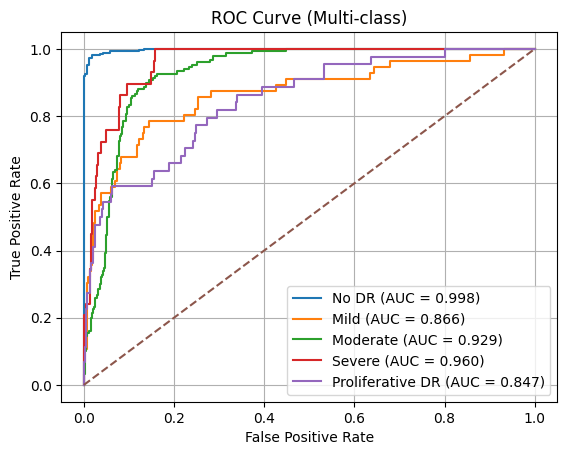

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_pred_probs, class_names):
    num_classes = len(class_names)

    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    plt.figure()

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
        )

    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Multi-class)")
    plt.legend()
    plt.grid()
    plt.show()

plot_roc_curve(true_labels, all_test_predictions, CLASSES)

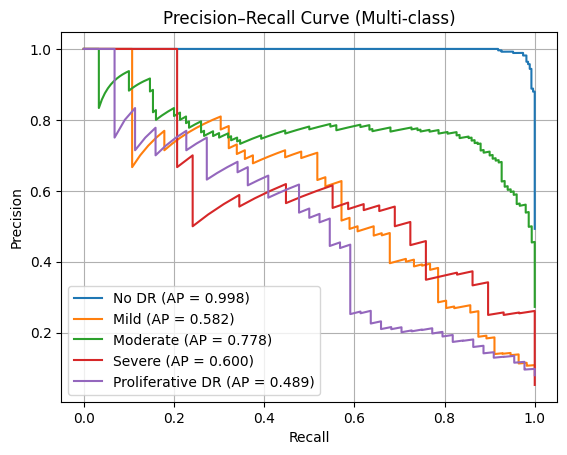

In [24]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall(y_true, y_pred_probs, class_names):
    num_classes = len(class_names)

    # Convert labels to one-vs-rest format
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    plt.figure()

    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(
            y_true_bin[:, i],
            y_pred_probs[:, i]
        )

        ap_score = average_precision_score(
            y_true_bin[:, i],
            y_pred_probs[:, i]
        )

        plt.plot(
            recall,
            precision,
            label=f"{class_names[i]} (AP = {ap_score:.3f})"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curve (Multi-class)")
    plt.legend()
    plt.grid()
    plt.show()

plot_precision_recall(true_labels, all_test_predictions, CLASSES)

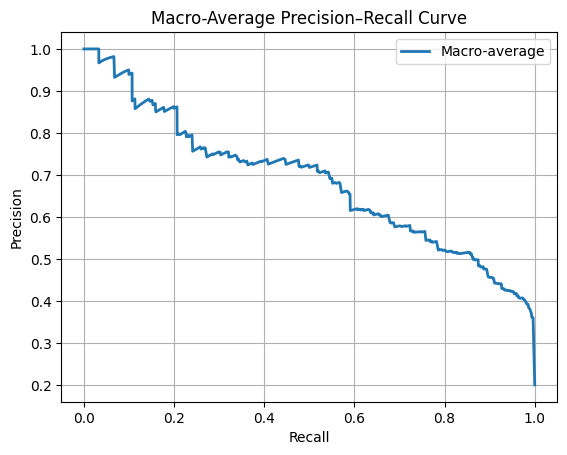

In [25]:
def plot_macro_pr(y_true, y_pred_probs, class_names):
    num_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    precision = dict()
    recall = dict()

    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(
            y_true_bin[:, i],
            y_pred_probs[:, i]
        )

    # Macro average
    all_recall = np.unique(np.concatenate([recall[i] for i in range(num_classes)]))
    mean_precision = np.zeros_like(all_recall)

    for i in range(num_classes):
        mean_precision += np.interp(all_recall, recall[i][::-1], precision[i][::-1])

    mean_precision /= num_classes

    plt.figure()
    plt.plot(all_recall, mean_precision, label="Macro-average", linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Macro-Average Precision–Recall Curve")
    plt.legend()
    plt.grid()
    plt.show()

plot_macro_pr(true_labels, all_test_predictions, CLASSES)

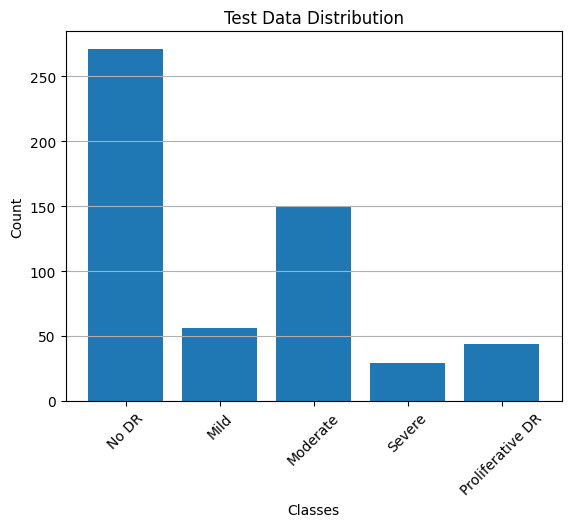

In [26]:
def plot_class_distribution(labels, class_names, title="Class Distribution"):
    counts = [np.sum(labels == i) for i in range(len(class_names))]

    plt.figure()
    plt.bar(class_names, counts)
    plt.title(title)
    plt.xlabel("Classes")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()

plot_class_distribution(true_labels, CLASSES, "Test Data Distribution")

In [27]:
def plot_prediction_samples(images, true_labels, preds, class_names, num=6):
    plt.figure(figsize=(12, 8))

    for i in range(num):
        plt.subplot(2, 3, i+1)

        img = images[i].permute(1, 2, 0).cpu().numpy()
        plt.imshow(img)

        true = class_names[true_labels[i]]
        pred = class_names[preds[i]]

        color = "green" if true == pred else "red"
        plt.title(f"T: {true}\nP: {pred}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

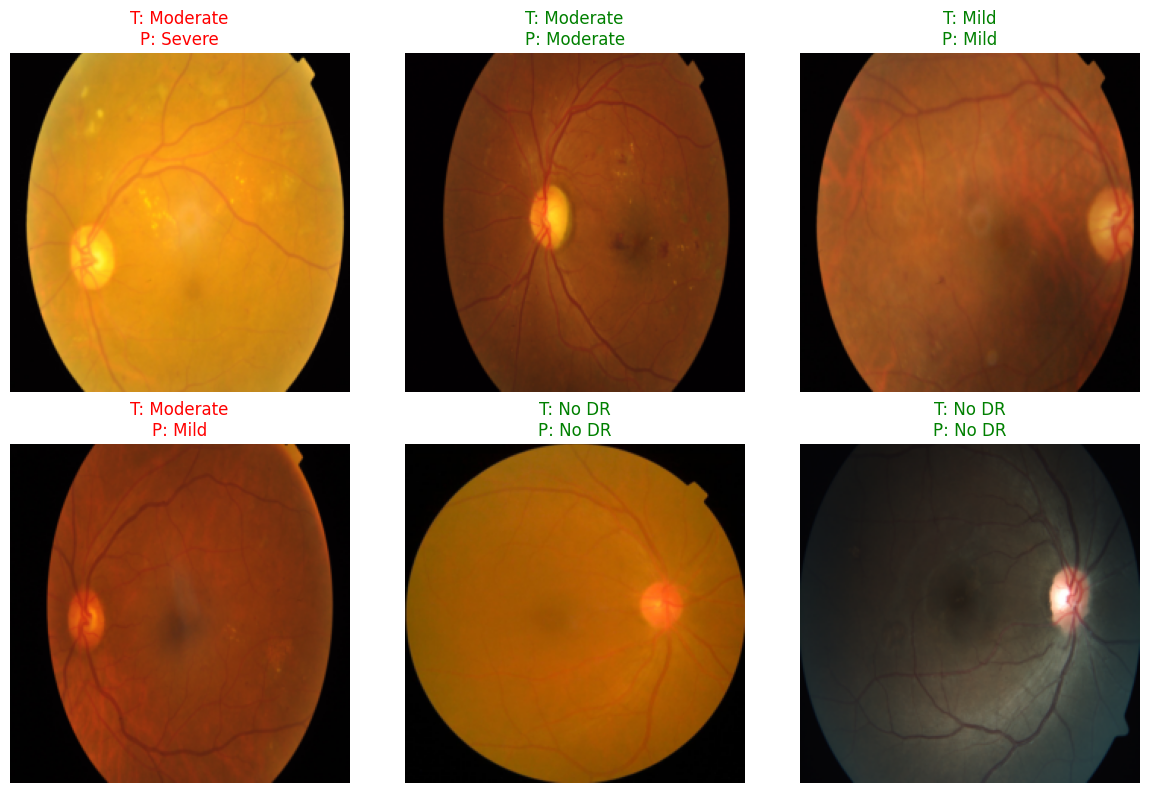

In [28]:
data_iter = iter(test_loader)
images, labels = next(data_iter)

outputs = model(images.to(device))
preds = torch.argmax(outputs, dim=1).cpu().numpy()

plot_prediction_samples(images, labels.numpy(), preds, CLASSES)